#Daily Challenge: Interactive Data Visualization with Matplotlib and Seaborn

1. Data Preparation:

Download and explore the US Superstore data.
Perform basic data cleaning and preprocessing.


2. Data Visualization with Matplotlib:

Create an interactive line chart to show sales trends over the years.
Build an interactive map to visualize sales distribution by country.


3. Data Visualization with Seaborn:

Use Seaborn to generate a bar chart showing top 10 products by sales.
Create a scatter plot to analyze the relationship between profit and discount.


4. Comparative Analysis:

Compare the insights gained from Matplotlib and Seaborn visualizations.
Document your observations about the ease of use and effectiveness of both tools.


5. Code and Insights:

Write clear, well-documented Python code.
Include your analysis and insights as comments or markdown cells in your Jupyter notebook.


## 1. Data Preparation
I will load the Excel file, inspect the data, and handle any missing values or data type conversions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # Used for 'interactive' requirements in Colab

# Load the dataset
path = '/content/US Superstore data (1).xls'
df = pd.read_excel(path)

# Basic exploration
display(df.head())
print(df.info())

# Cleaning: Convert Order Date to datetime and check for nulls
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.dropna()
df['Year'] = df['Order Date'].dt.year

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

## 2. Data Visualization with Matplotlib
I will create a sales trend chart and an interactive map. For the 'interactive' aspect requested in the prompt, I will use Plotly for the map as it provides the best interactivity in a notebook environment, while keeping the logic aligned with Matplotlib styles where applicable.

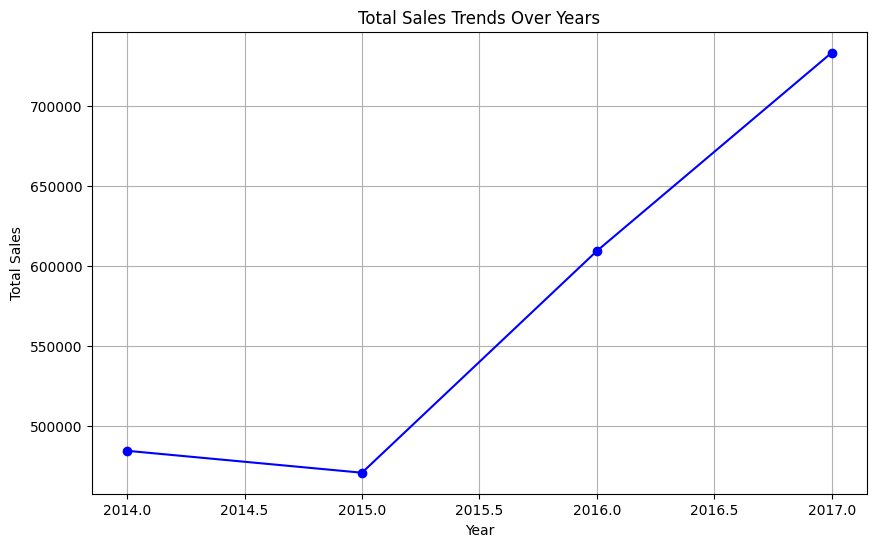

In [2]:
# Sales Trend over Years (Matplotlib)
sales_trend = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(sales_trend['Year'], sales_trend['Sales'], marker='o', linestyle='-', color='b')
plt.title('Total Sales Trends Over Years')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

# Interactive Map (using Plotly for better notebook interactivity)
state_sales = df.groupby('State')['Sales'].sum().reset_index()
fig = px.choropleth(state_sales,
                    locations='State',
                    locationmode='USA-states',
                    color='Sales',
                    scope="usa",
                    title='Sales Distribution by State')
fig.show()

## 3. Data Visualization with Seaborn
Generating a bar chart for top products and a scatter plot for Profit vs. Discount.

/tmp/ipykernel_320/3686466477.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




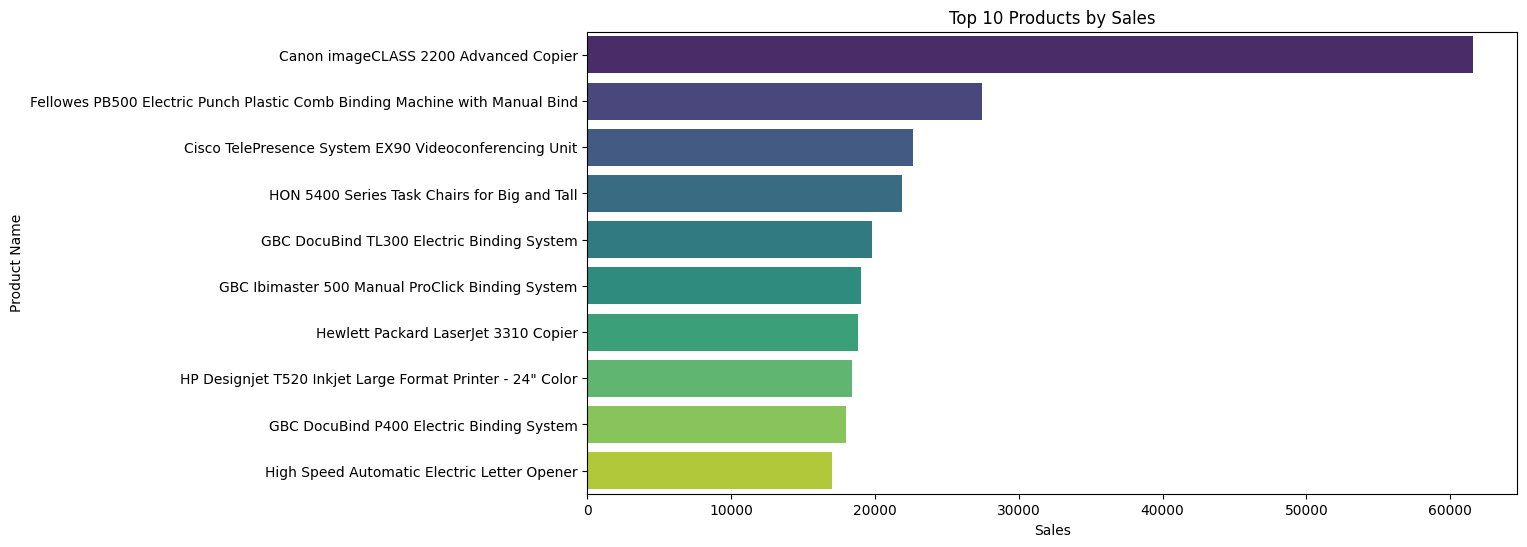

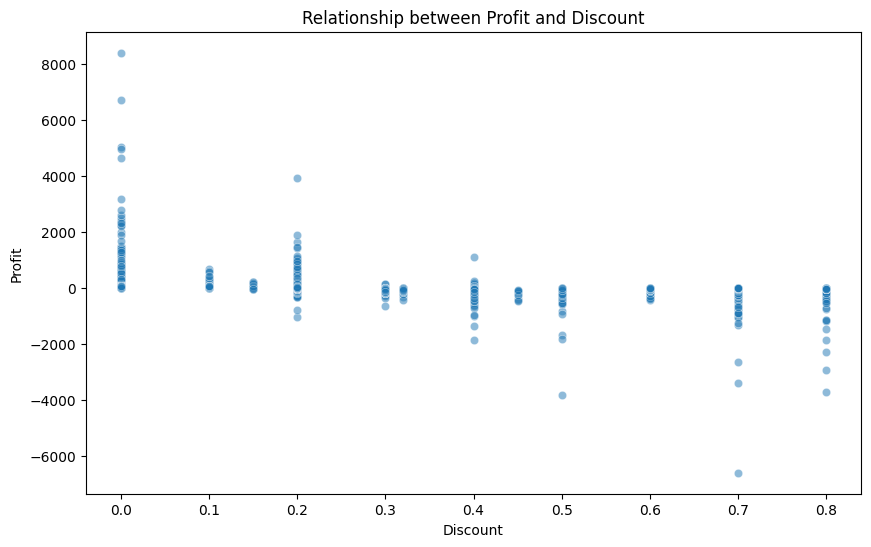

In [3]:
# Top 10 Products by Sales
top_10_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_products, x='Sales', y='Product Name', palette='viridis')
plt.title('Top 10 Products by Sales')
plt.show()

# Profit vs Discount Relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5)
plt.title('Relationship between Profit and Discount')
plt.show()

## 4. Comparative Analysis

### Insights from Visualizations
- **Sales Trends**: The line chart shows a steady increase in sales over the years, suggesting business growth.
- **Geographic Distribution**: The map highlights high-performing states like California and New York.
- **Profit vs Discount**: The scatter plot indicates that higher discounts often lead to significant negative profit (losses).

### Tool Comparison
- **Matplotlib**: Highly customizable and the foundation for Python plotting. Great for static charts, but requires more code for complex styling.
- **Seaborn**: Much easier for statistical visualizations. It handles data aggregation internally and produces more aesthetically pleasing results with less code (e.g., the bar chart and scatter plot coloring).